# DSA210 Term Project

Here is my exploratory data analysis (EDA) and hypothesis testing for the project.
I will look at the survey results to understand how noise and locations change focus levels.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

### 1. Data Cleaning
first i need to clean the dataset. google forms adds score and feedback columns automatically to every question so i have to drop them. i also need to rename the questions.

In [2]:
df = pd.read_csv('dataset/Blank Quiz.csv')

# dropping timestamp and total score
columns_to_drop = ['Timestamp', 'Total score']

# finding all the score and feedback columns to drop them
for col in df.columns:
    if "[Score]" in col or "[Feedback]" in col:
        columns_to_drop.append(col)

df.drop(columns=columns_to_drop, inplace=True)

# changing long question names to simple variables for easier coding
df.columns = [
    "year", "department", "study_hours", "location", 
    "noise_level", "audio", "social", "focus", 
    "productivity", "gpa", "sleep", "screen_time", "stress"
]

# making sure the numerical values are actually ints and not strings
df['noise_level'] = df['noise_level'].astype(int)
df['focus'] = df['focus'].astype(int)
df['productivity'] = df['productivity'].astype(int)
df['sleep'] = df['sleep'].astype(int)
df['screen_time'] = df['screen_time'].astype(int)
df['stress'] = df['stress'].astype(int)

df.head()

,year,department,study_hours,location,noise_level,audio,social,focus,productivity,gpa,sleep,screen_time,stress
0,3rd year,Business,0-2 hours,Puplic study area,3,"Yes, Lyrical (Pop, Rock)",Alone,8,7,3.0-3.5,9,6,6
1,4th year,Psychology,6+ hours,Home,2,"Yes, Lyrical (Pop, Rock)",With friends,6,7,3.0-3.5,9,4,6
2,3rd year,Psychology,6+ hours,Puplic study area,2,"Yes, Other",Alone,8,7,3.5-4.0,8,2,7
3,3rd year,Design,0-2 hours,Puplic study area,3,"Yes, Ambient (White noise, Nature)",With friends,8,9,3.0-3.5,9,8,5
4,4th year,Computer Science,6+ hours,Cafe,3,"Yes, Lyrical (Pop, Rock)",Around people but working independently,6,6,Below 2.0,9,8,6


### 2. Exploratory Data Analysis
plotting some relations to see what is going on in the data.

Text(0, 0.5, 'focus score')

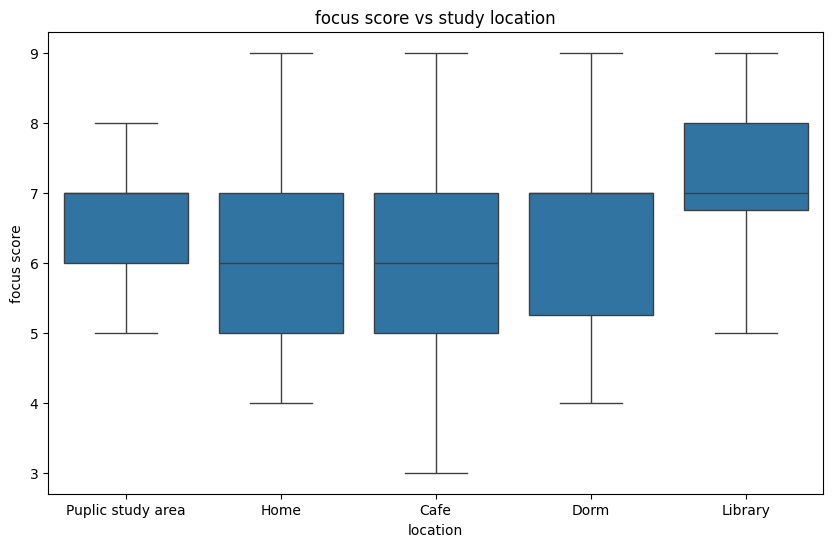

In [3]:
# boxplot for location vs focus
plt.figure(figsize=(10,6))
sns.boxplot(x="location", y="focus", data=df)
plt.title("focus score vs study location")
plt.xlabel("location")
plt.ylabel("focus score")

Text(0.5, 1.0, 'productivity distribution')

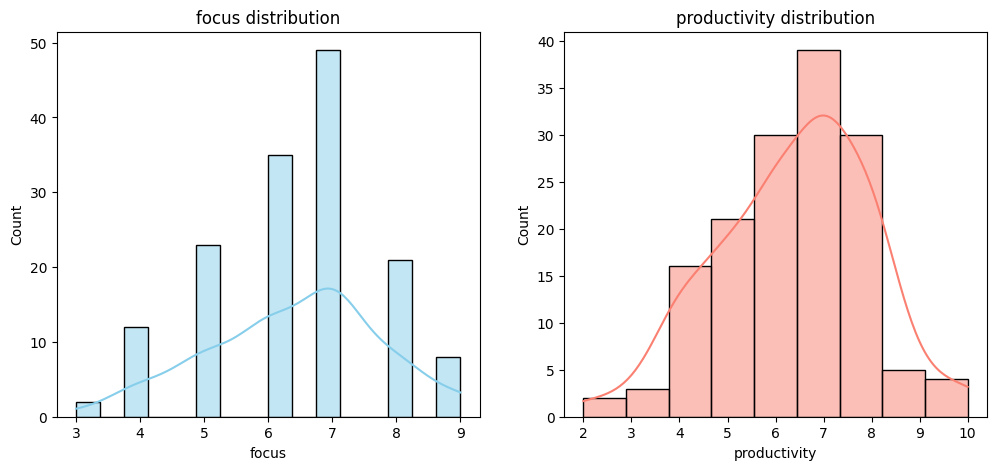

In [4]:
# dist plots for focus and productivity
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['focus'], kde=True, color='skyblue')
plt.title('focus distribution')

plt.subplot(1, 2, 2)
sns.histplot(df['productivity'], kde=True, color='salmon')
plt.title('productivity distribution')

C:\Users\kosot\AppData\Local\Temp\ipykernel_2096\2469069614.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='department', data=df, palette='viridis')


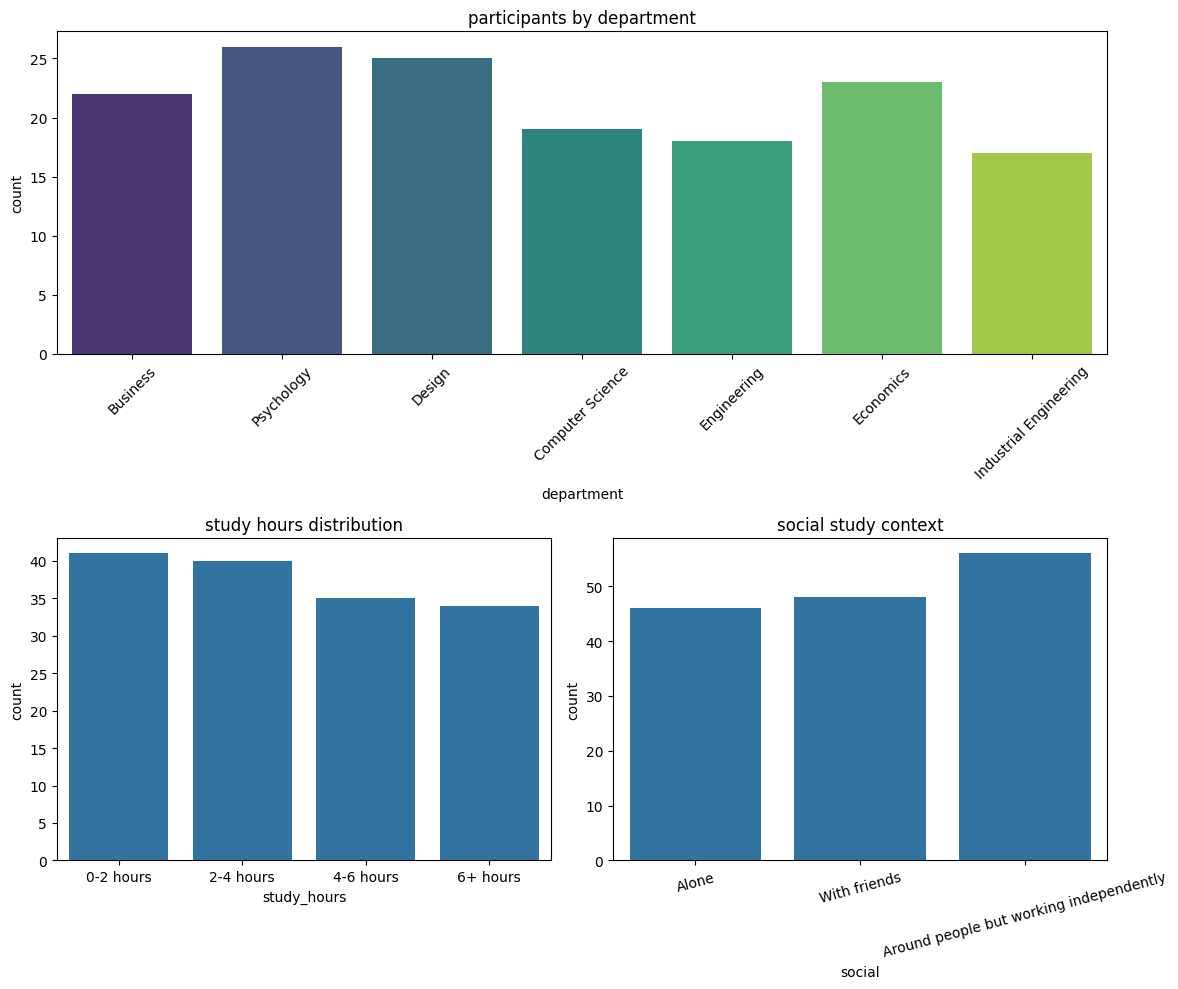

In [5]:
# participants profile - categorical count plots
plt.figure(figsize=(12, 10))

plt.subplot(2, 1, 1)
sns.countplot(x='department', data=df, palette='viridis')
plt.title('participants by department')
plt.xticks(rotation=45)

plt.subplot(2, 2, 3)
sns.countplot(x='study_hours', data=df, order=['0-2 hours', '2-4 hours', '4-6 hours', '6+ hours'])
plt.title('study hours distribution')

plt.subplot(2, 2, 4)
sns.countplot(x='social', data=df)
plt.title('social study context')
plt.xticks(rotation=15)

plt.tight_layout()

In [10]:
# pivot table - mean focus by location and social context
print("average focus scores (location vs social):")
pivot_focus = df.pivot_table(index='location', columns='social', values='focus', aggfunc='mean')
pivot_focus 

average focus scores (location vs social):


social,Alone,Around people but working independently,With friends
location,,,
Cafe,6.100000,6.000000,5.909091
Dorm,6.300000,6.076923,6.571429
Home,6.300000,6.571429,6.000000
Library,6.857143,7.500000,6.571429
Puplic study area,6.888889,6.111111,7.000000


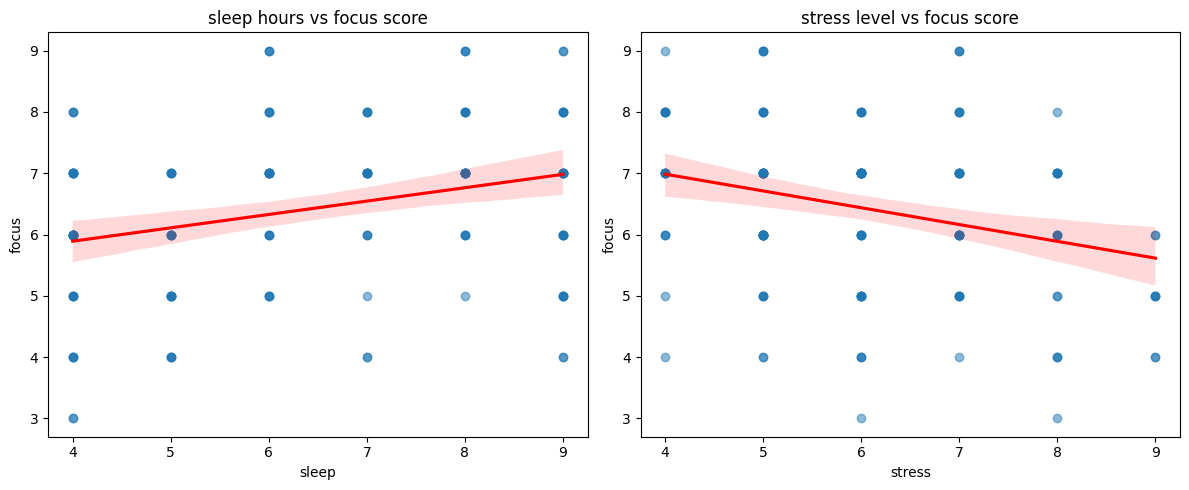

In [11]:
# scatter plots with regression - sleep and stress vs focus
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.regplot(x='sleep', y='focus', data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('sleep hours vs focus score')

plt.subplot(1, 2, 2)
sns.regplot(x='stress', y='focus', data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('stress level vs focus score')

plt.tight_layout()

### 3. Hypothesis Testing
now i will test if noise level really affects focus.

**Hypotheses:**
- **H0 (Null Hypothesis):** there is no difference in focus between low noise (1-2) and high noise (3-5) groups.
- **H1 (Alternative Hypothesis):** focus is higher in the low noise group compared to high noise group.

In [12]:
# separating students by their environment noise level
low_noise_students = df[df['noise_level'] <= 2]['focus']
high_noise_students = df[df['noise_level'] > 2]['focus']

print("Average focus for low noise:", low_noise_students.mean())
print("Average focus for high noise:", high_noise_students.mean())

# calculating independent t-test (variances are likely not equal)
t_stat, p_val = stats.ttest_ind(low_noise_students, high_noise_students, equal_var=False)

print("t-statistic:", t_stat)
print("p-value:", p_val)

alpha = 0.05
if p_val < alpha:
    print("reject null hypothesis because p-value is smaller than 0.05.")
    print("we found strong evidence that noise level affects focus scores.")
else:
    print("fail to reject null hypothesis. no significant effect observed.")

Average focus for low noise: 6.917808219178082
Average focus for high noise: 5.935064935064935
t-statistic: 4.829332406938804
p-value: 3.4475782438007284e-06
reject null hypothesis because p-value is smaller than 0.05.
we found strong evidence that noise level affects focus scores.


**Conclusion:**
since p-value is much smaller than 0.05, we reject the null hypothesis. this means the environment noise actually has a significant effect on student focus.